In [41]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict

In [42]:
class State(TypedDict):
  messages: Annotated[list, add_messages]

In [43]:
graph_builder = StateGraph(State)

In [44]:
import os
from dotenv import load_dotenv

load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

In [45]:
from langchain_groq import ChatGroq

# LLM Initialization 
llm = ChatGroq(model_name="llama-3.3-70b-versatile")

In [46]:
# Defining tools for llm
from langchain_community.utilities import ArxivAPIWrapper
from langchain_community.tools.arxiv.tool import ArxivQueryRun

arxiv_api_wrapper = ArxivAPIWrapper(top_k_results=4, doc_content_chars_max=2000)
arxiv = ArxivQueryRun(api_wrapper=arxiv_api_wrapper)
arxiv.invoke("tell me about the demand of agentic ai engineers")

'Published: 2026-05-17\nTitle: Towards trustworthy agentic AI: a comprehensive survey of safety, robustness, privacy, and system security\nAuthors: Jinhu Qi, Muzhi Li, Jiahong Liu, Yuqin Shu, Dianzhi Yu, Shicheng Ma, Wenqian Cui, Yiyang Zhao, Yiyi Chen, Ruoxi Jiang, Irwin King, Zenglin Xu\nSummary: Agentic AI systems -- Large Language Models (LLMs) augmented with planning, tool use, memory, and long-horizon interactions -- can execute complex tasks autonomously, but their multi-step trajectories introduce new failure modes that challenge trustworthiness. This survey provides a focused examination of trustworthy agentic AI through two core dimensions that are critical for high-risk deployments: Safety and Robustness, and Privacy and System Security. For each dimension, we clarify key concepts, identify where risks emerge along the agent workflow, and summarize stage-targeted mitigation strategies. Other trustworthiness aspects (value alignment, transparency, fairness, and accountability

In [47]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

In [48]:
tools = [arxiv, tavily]

In [49]:
llm_with_tools = llm.bind_tools(tools=tools)

In [50]:
llm_with_tools.invoke("Tell me about the demand of agentic ai engineers in 2030")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '3qfrcbry6', 'function': {'arguments': '{"query":"agentic AI engineers demand 2030"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 441, 'total_tokens': 466, 'completion_time': 0.076436558, 'completion_tokens_details': None, 'prompt_time': 0.026088078, 'prompt_tokens_details': None, 'queue_time': 0.008252054, 'total_time': 0.102524636}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eca86-96cd-7a43-a96a-af39455c946c-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'agentic AI engineers demand 2030'}, 'id': '3qfrcbry6', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 441, 'output_tokens': 25, 'total_tokens': 466})

In [51]:
# Node Definition
def tool_calling_llm_chatbot(state: State):
  print('current state', state)
  return {"messages": [llm.invoke(state["messages"])]}

In [52]:
from langgraph.prebuilt import ToolNode, tools_condition

In [53]:
# Adding nodes - Here we are creating only one node as we have only one
graph_builder.add_node('tool_calling_llm_chatbot', tool_calling_llm_chatbot)
graph_builder.add_node('tools', ToolNode(tools))

# Adding edges
graph_builder.add_edge(START, 'tool_calling_llm_chatbot')
graph_builder.add_conditional_edges(
  "tool_calling_llm_chatbot", tools_condition
)
graph_builder.add_edge('tools', "tool_calling_llm_chatbot")

# Compiling the graph
graph = graph_builder.compile()


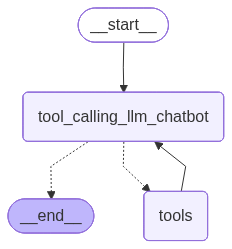

In [54]:
# Visualizing the graph
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [57]:
response = graph.invoke({"messages": "how will the world solve the energy and cost problem of ai agents and data centres? analyze it deeply"})

for res in response["messages"]:
  res.pretty_print()

current state {'messages': [HumanMessage(content='how will the world solve the energy and cost problem of ai agents and data centres? analyze it deeply', additional_kwargs={}, response_metadata={}, id='eaf09fd4-f4c6-4286-ae9f-649526041501')]}
================================ Human Message =================================

how will the world solve the energy and cost problem of ai agents and data centres? analyze it deeply
================================== Ai Message ==================================

The energy and cost problem of AI agents and data centers is a pressing concern that requires a multifaceted solution. As AI continues to advance and become increasingly ubiquitous, the energy consumption and costs associated with training, deploying, and maintaining AI models are becoming unsustainable. Here's a deep analysis of the problem and potential solutions:

**The Problem:**

1. **Energy Consumption:** Training large AI models requires massive amounts of computational power, wh